In [6]:
# Packages Installation
!pip install pyarrow
!pip install pandas
!pip install pillow
!pip install torch torchvision scikit-learn

In [7]:
# Importing Libraries
import os
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)

# Random Seed for Reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [8]:
# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Dataset Loading

In [9]:
train_files = [
"/content/train-00000-of-00007.parquet",
"/content/train-00001-of-00007.parquet",
"/content/train-00002-of-00007.parquet",
"/content/train-00003-of-00007.parquet",
"/content/train-00004-of-00007.parquet",
"/content/train-00005-of-00007.parquet",
"/content/train-00006-of-00007.parquet"
]

train_dfs = []

for file in train_files:
    df = pd.read_parquet(file)
    train_dfs.append(df)

train_df = pd.concat(train_dfs, ignore_index=True)

print("Train Dataset Shape:", train_df.shape)

Train Dataset Shape: (5216, 2)


In [10]:
test_df = pd.read_parquet("/content/test-00000-of-00001.parquet")

print("Test Dataset Shape:", test_df.shape)

Test Dataset Shape: (624, 2)


In [11]:
val_df = pd.read_parquet("/content/validation-00000-of-00001.parquet")

print("Validation Dataset Shape:", val_df.shape)

Validation Dataset Shape: (16, 2)


In [12]:
train_df.head()

,image,label
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0


In [13]:
train_df['label'].value_counts()

,count
label,
1,3875
0,1341


Pneumonia: 3875
Normal: 1341


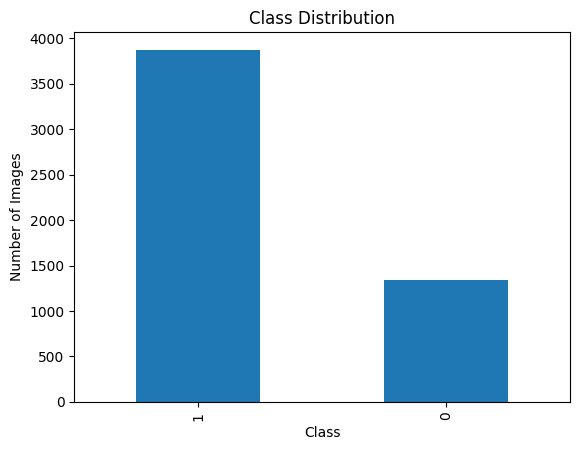

In [14]:
pneumonia = train_df[train_df['label'] == 1]
normal = train_df[train_df['label'] == 0]

print("Pneumonia:", len(pneumonia))
print("Normal:", len(normal))
train_df['label'].value_counts().plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [15]:
normal_upsampled = resample(
    normal,
    replace=True,            # sample with replacement
    n_samples=len(pneumonia),
    random_state=42
)

In [16]:
balanced_train_df = pd.concat([pneumonia, normal_upsampled])

balanced_train_df = balanced_train_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [17]:
balanced_train_df['label'].value_counts()

,count
label,
1,3875
0,3875


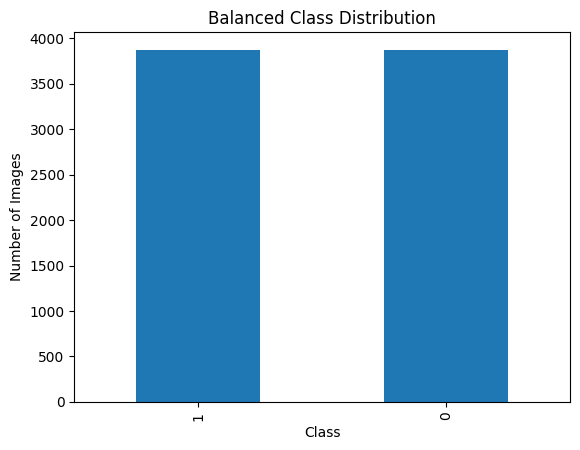

In [18]:
balanced_train_df['label'].value_counts().plot(kind='bar')

plt.title("Balanced Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

(np.float64(-0.5), np.float64(871.5), np.float64(511.5), np.float64(-0.5))

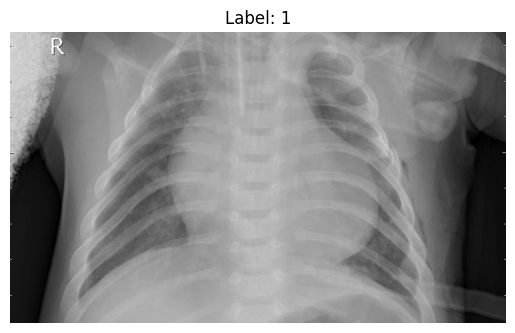

In [19]:
sample = balanced_train_df.iloc[0]
image_data = sample["image"]
label = sample["label"]

# Convert to PIL image
image = Image.open(io.BytesIO(image_data["bytes"]))

plt.imshow(image, cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")

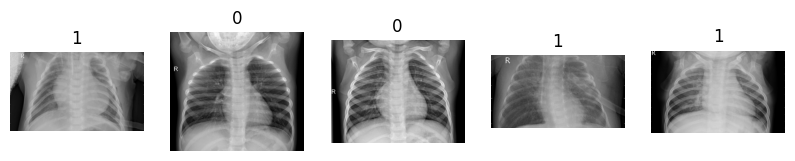

In [20]:
plt.figure(figsize=(10,5))

for i in range(5):

    sample = balanced_train_df.iloc[i]

    image = Image.open(io.BytesIO(sample["image"]["bytes"]))
    label = sample["label"]

    plt.subplot(1,5,i+1)
    plt.imshow(image, cmap="gray")
    plt.title(label)
    plt.axis("off")

plt.show()

In [21]:
train_df, val_df = train_test_split(
    balanced_train_df,
    test_size=0.1,
    stratify=balanced_train_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 6975
Validation: 775
Test: 624


In [22]:
train_transforms = transforms.Compose([

    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [23]:
test_transforms = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [24]:
class PneumoniaDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        sample = self.dataframe.iloc[idx]

        image_bytes = sample["image"]["bytes"]
        label = sample["label"]

        image = Image.open(io.BytesIO(image_bytes)).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [25]:
train_dataset = PneumoniaDataset(train_df, transform=train_transforms)

val_dataset = PneumoniaDataset(val_df, transform=test_transforms)

test_dataset = PneumoniaDataset(test_df, transform=test_transforms)

In [26]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

In [27]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


# CNN Model

In [28]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv_layers = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(128*28*28,256),
            nn.ReLU(),
            nn.Linear(256,2)
        )
    def forward(self,x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

In [29]:
model = CNNModel()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

CNNModel(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=100352, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=2, bias=True)
  )
)

In [30]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [31]:
train_losses = []
val_accuracies = []

num_epochs = 10

for epoch in range(num_epochs):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    # Validation Accuracy
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Val Accuracy: {val_acc:.4f}")

Epoch 1, Loss: 0.2535, Val Accuracy: 0.9703
Epoch 2, Loss: 0.1214, Val Accuracy: 0.9677
Epoch 3, Loss: 0.0957, Val Accuracy: 0.9768
Epoch 4, Loss: 0.0784, Val Accuracy: 0.9819
Epoch 5, Loss: 0.0710, Val Accuracy: 0.9690
Epoch 6, Loss: 0.0621, Val Accuracy: 0.9832
Epoch 7, Loss: 0.0539, Val Accuracy: 0.9819
Epoch 8, Loss: 0.0493, Val Accuracy: 0.9819
Epoch 9, Loss: 0.0443, Val Accuracy: 0.9781
Epoch 10, Loss: 0.0381, Val Accuracy: 0.9871


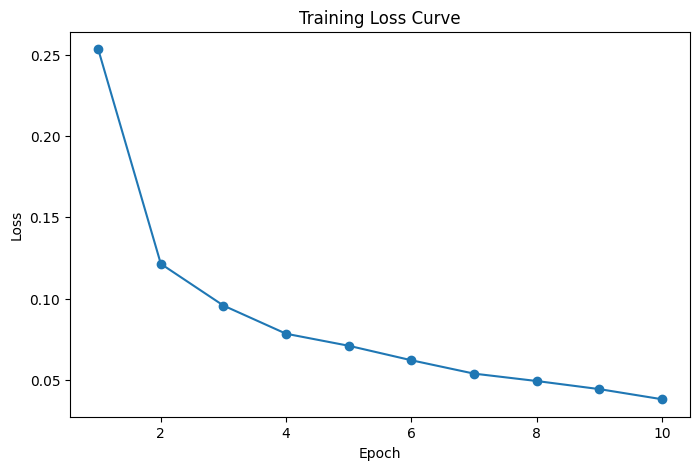

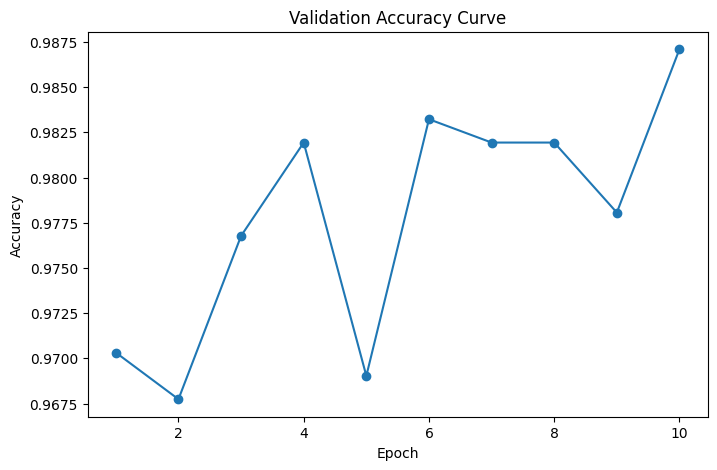

In [32]:
# Plot Loss Curve
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs+1), train_losses, marker='o')
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


# Plot Accuracy Curve
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs+1), val_accuracies, marker='o')
plt.title("Validation Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [33]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Save CNN results
cnn_labels = all_labels
cnn_predictions = all_preds

In [34]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.97      0.50      0.66       234
           1       0.77      0.99      0.86       390

    accuracy                           0.80       624
   macro avg       0.87      0.74      0.76       624
weighted avg       0.84      0.80      0.79       624



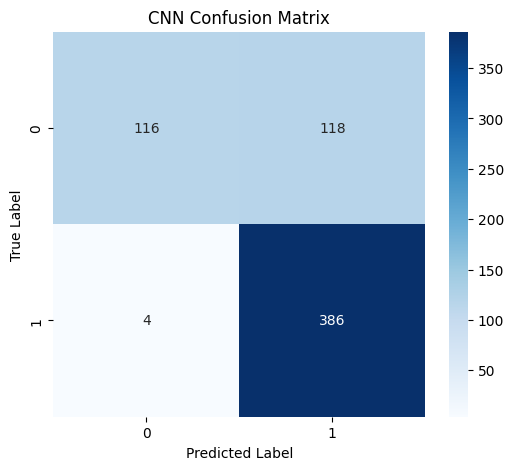

In [35]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN Confusion Matrix")
plt.show()

In [36]:
all_probs = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:,1]
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

# Save CNN probabilities
cnn_probs = all_probs

print("AUC Score:", roc_auc)

AUC Score: 0.9173350865658558


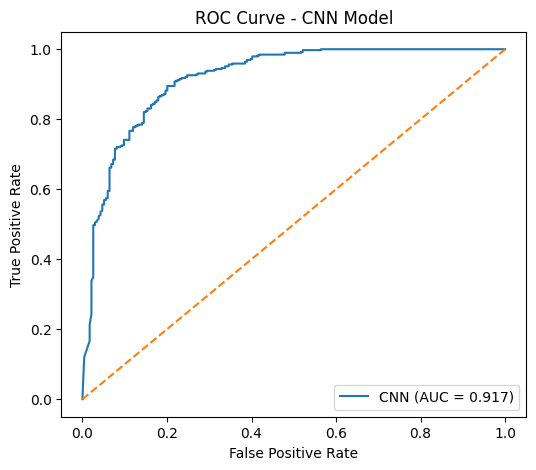

In [37]:
# Plot ROC Curve for CNN
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"CNN (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CNN Model")
plt.legend()
plt.show()

# Transfer Learning Model (ResNet50)

In [38]:
# Load Pretrained ResNet50
resnet_model = models.resnet50(pretrained=True)

# Replace final layer
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 2)

resnet_model = resnet_model.to(device)

print(resnet_model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 205MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [39]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(resnet_model.parameters(), lr=0.0001)

In [40]:
# Training ResNet50 Model
resnet_train_losses = []
resnet_val_acc = []

num_epochs = 10

for epoch in range(num_epochs):

    resnet_model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = resnet_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    resnet_train_losses.append(epoch_loss)

    # Validation Accuracy
    resnet_model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = resnet_model(images)

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = correct / total
    resnet_val_acc.append(val_accuracy)

    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Val Acc: {val_accuracy:.4f}")

Epoch 1, Loss: 0.0984, Val Acc: 0.9897
Epoch 2, Loss: 0.0418, Val Acc: 0.9897
Epoch 3, Loss: 0.0340, Val Acc: 0.9884
Epoch 4, Loss: 0.0198, Val Acc: 0.9845
Epoch 5, Loss: 0.0297, Val Acc: 0.9806
Epoch 6, Loss: 0.0166, Val Acc: 0.9871
Epoch 7, Loss: 0.0107, Val Acc: 0.9935
Epoch 8, Loss: 0.0100, Val Acc: 0.9974
Epoch 9, Loss: 0.0138, Val Acc: 0.9910
Epoch 10, Loss: 0.0114, Val Acc: 0.9974


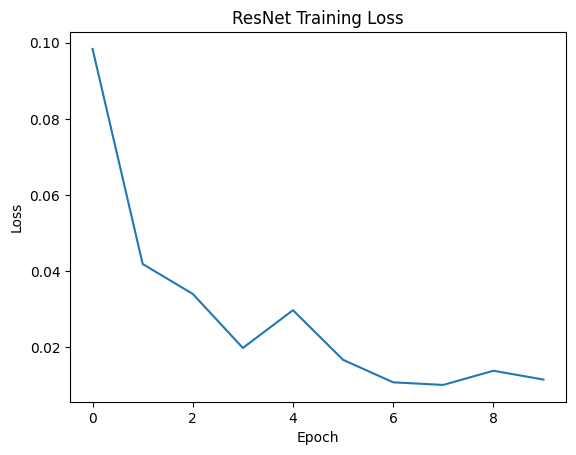

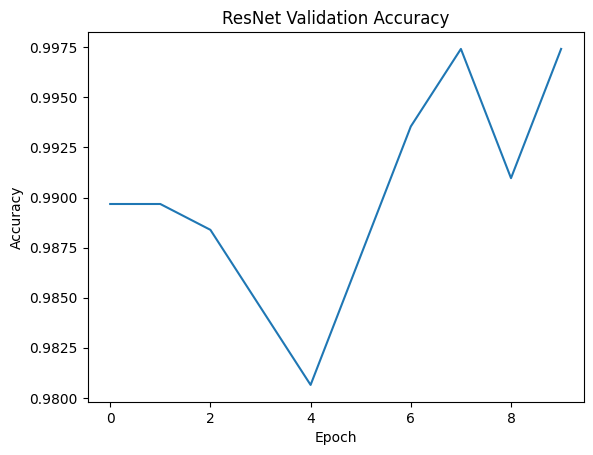

In [41]:
plt.plot(resnet_train_losses)
plt.title("ResNet Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.plot(resnet_val_acc)
plt.title("ResNet Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [42]:
resnet_preds = []
resnet_labels = []

resnet_model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = resnet_model(images)

        _, preds = torch.max(outputs,1)

        resnet_preds.extend(preds.cpu().numpy())
        resnet_labels.extend(labels.numpy())

# Save ResNet results
resnet_true = resnet_labels
resnet_predictions = resnet_preds

In [43]:
print(classification_report(resnet_labels, resnet_preds))

              precision    recall  f1-score   support

           0       0.99      0.60      0.75       234
           1       0.81      1.00      0.89       390

    accuracy                           0.85       624
   macro avg       0.90      0.80      0.82       624
weighted avg       0.88      0.85      0.84       624



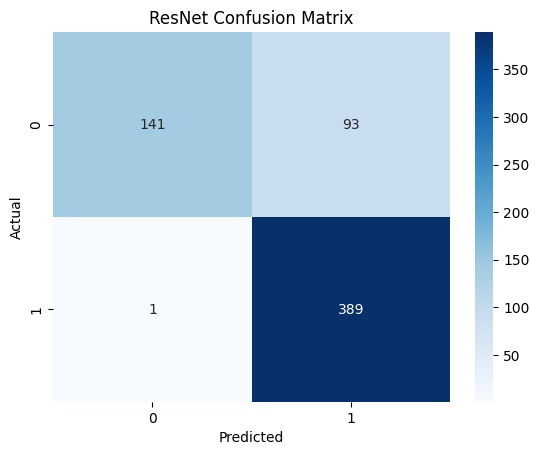

In [44]:
cm = confusion_matrix(resnet_labels, resnet_preds)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("ResNet Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [45]:
resnet_probs = []
resnet_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = resnet_model(images)

        probs = torch.softmax(outputs, dim=1)[:,1]

        resnet_probs.extend(probs.cpu().numpy())
        resnet_labels.extend(labels.numpy())

fpr, tpr, _ = roc_curve(resnet_labels, resnet_probs)

resnet_auc = auc(fpr, tpr)

print("ResNet AUC:", resnet_auc)

ResNet AUC: 0.979278983125137


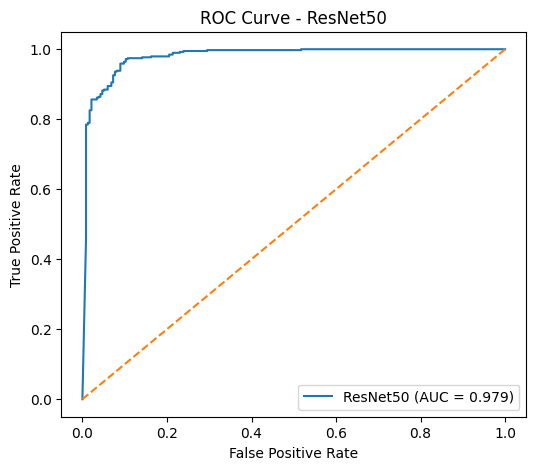

In [46]:
# Plot ROC Curve for ResNet50
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"ResNet50 (AUC = {resnet_auc:.3f})")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ResNet50")
plt.legend()
plt.show()

# Machine Learning Models Implementation

**Feature Extraction for Machine Learning Models**

In [48]:
# Creating Feature Extractor
feature_extractor = models.resnet50(pretrained=True)
feature_extractor.fc = nn.Identity()
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [49]:
# Extract Features
X_train = []
y_train = []

with torch.no_grad():
    for images, labels in train_loader:

        images = images.to(device)

        features = feature_extractor(images)

        X_train.extend(features.cpu().numpy())
        y_train.extend(labels.numpy())

X_train = np.array(X_train)
y_train = np.array(y_train)

In [50]:
# Extract Test Features
X_test = []
y_test = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        features = feature_extractor(images)

        X_test.extend(features.cpu().numpy())
        y_test.extend(labels.numpy())

X_test = np.array(X_test)
y_test = np.array(y_test)

# Random Forest Model

In [51]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [52]:
rf_preds = rf_model.predict(X_test)
print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       0.86      0.75      0.80       234
           1       0.86      0.93      0.89       390

    accuracy                           0.86       624
   macro avg       0.86      0.84      0.85       624
weighted avg       0.86      0.86      0.86       624



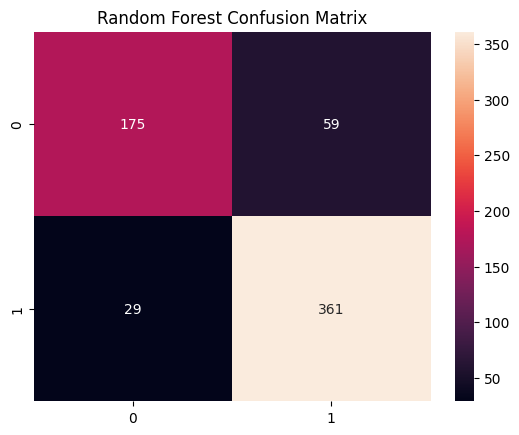

In [53]:
cm = confusion_matrix(y_test, rf_preds)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Random Forest Confusion Matrix")

plt.show()

# Support Vector Machine (SVM)

In [54]:
svm_model = SVC(kernel='rbf', probability=True)
svm_model.fit(X_train, y_train)


SVC(probability=True)

In [55]:
svm_preds = svm_model.predict(X_test)
print(classification_report(y_test, svm_preds))

              precision    recall  f1-score   support

           0       0.95      0.77      0.85       234
           1       0.88      0.98      0.92       390

    accuracy                           0.90       624
   macro avg       0.91      0.87      0.89       624
weighted avg       0.90      0.90      0.90       624



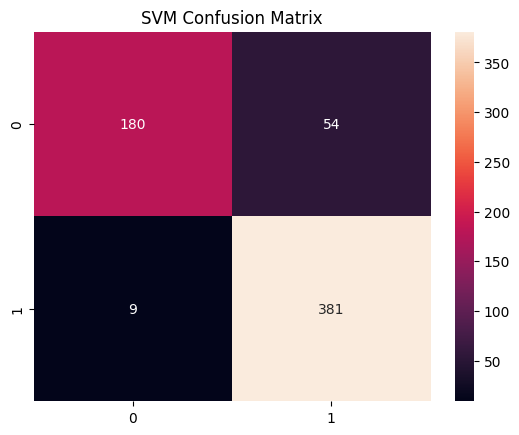

In [56]:
cm = confusion_matrix(y_test, svm_preds)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("SVM Confusion Matrix")

plt.show()

In [57]:
cnn_acc = accuracy_score(cnn_labels, cnn_predictions)
rf_acc = accuracy_score(y_test, rf_preds)
svm_acc = accuracy_score(y_test, svm_preds)
resnet_acc = accuracy_score(resnet_true, resnet_predictions)

results = pd.DataFrame({
    "Model":["Random Forest","SVM","CNN","ResNet50"],
    "Accuracy":[rf_acc, svm_acc, cnn_acc, resnet_acc]
})

print(results)

           Model  Accuracy
0  Random Forest  0.858974
1            SVM  0.899038
2            CNN  0.804487
3       ResNet50  0.849359


In [58]:
def calculate_metrics(y_true, y_pred, y_prob=None):

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)

    sensitivity = tp / (tp + fn)   # Recall for Positive Class

    specificity = tn / (tn + fp)

    if y_prob is not None:
        auc = roc_auc_score(y_true, y_prob)
    else:
        auc = None

    return accuracy, sensitivity, specificity, auc

In [59]:
cnn_accuracy, cnn_sensitivity, cnn_specificity, cnn_auc = calculate_metrics(
    cnn_labels, cnn_predictions, cnn_probs
)
resnet_accuracy, resnet_sensitivity, resnet_specificity, resnet_auc = calculate_metrics(
    resnet_true, resnet_predictions, resnet_probs
)
rf_probs = rf_model.predict_proba(X_test)[:,1]

rf_accuracy, rf_sensitivity, rf_specificity, rf_auc = calculate_metrics(
    y_test, rf_preds, rf_probs
)
svm_probs = svm_model.predict_proba(X_test)[:,1]

svm_accuracy, svm_sensitivity, svm_specificity, svm_auc = calculate_metrics(
    y_test, svm_preds, svm_probs
)


In [60]:
results = pd.DataFrame({
    "Model": ["Random Forest", "SVM", "CNN", "ResNet50"],
    "Accuracy": [rf_accuracy, svm_accuracy, cnn_accuracy, resnet_accuracy],
    "Sensitivity": [rf_sensitivity, svm_sensitivity, cnn_sensitivity, resnet_sensitivity],
    "Specificity": [rf_specificity, svm_specificity, cnn_specificity, resnet_specificity],
    "AUC": [rf_auc, svm_auc, cnn_auc, resnet_auc]
})

print(results)

           Model  Accuracy  Sensitivity  Specificity       AUC
0  Random Forest  0.858974     0.925641     0.747863  0.941316
1            SVM  0.899038     0.976923     0.769231  0.963588
2            CNN  0.804487     0.989744     0.495726  0.917335
3       ResNet50  0.849359     0.997436     0.602564  0.979279


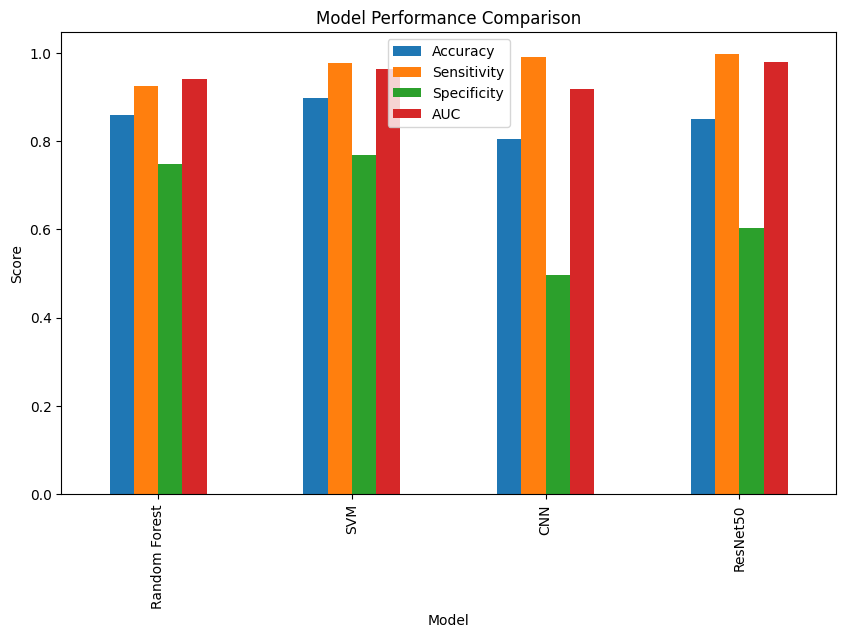

In [61]:
results.set_index("Model")[["Accuracy","Sensitivity","Specificity","AUC"]].plot(kind="bar", figsize=(10,6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()